<a href="https://colab.research.google.com/github/hitanshu5/Outlet-Sales-Prediction/blob/main/SalesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikit-learn==1.2.2

In [ ]:
pip install xgboost==1.7.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 4.3 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.3
    Uninstalling xgboost-2.1.3:
      Successfully uninstalled xgboost-2.1.3


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
data = pd.read_csv('/content/SalesPrediction.csv')

In [ ]:
data.head(2)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228


In [ ]:
data.shape

(8523, 12)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
data.duplicated().sum()

0

In [ ]:
data['Item_Identifier'].nunique()

1559

In [ ]:
data.drop(columns=['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)

In [ ]:
data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)

<ipython-input-15-4cade6002097>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)


In [ ]:
data['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [ ]:
mode_outlet_size = data.pivot_table(values='Outlet_Size',columns='Outlet_Type',aggfunc=lambda x: x.mode()[0])

In [ ]:
mode_outlet_size

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [ ]:
null = data['Outlet_Size'].isnull()

In [ ]:
null.value_counts()

,count
Outlet_Size,
False,6113
True,2410


In [ ]:
data.loc[null,'Outlet_Size'] = data.loc[null,'Outlet_Type'].apply(lambda x: mode_outlet_size[x])

In [ ]:
data.isnull().sum()

,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0
Outlet_Type,0
Item_Outlet_Sales,0


In [ ]:
data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


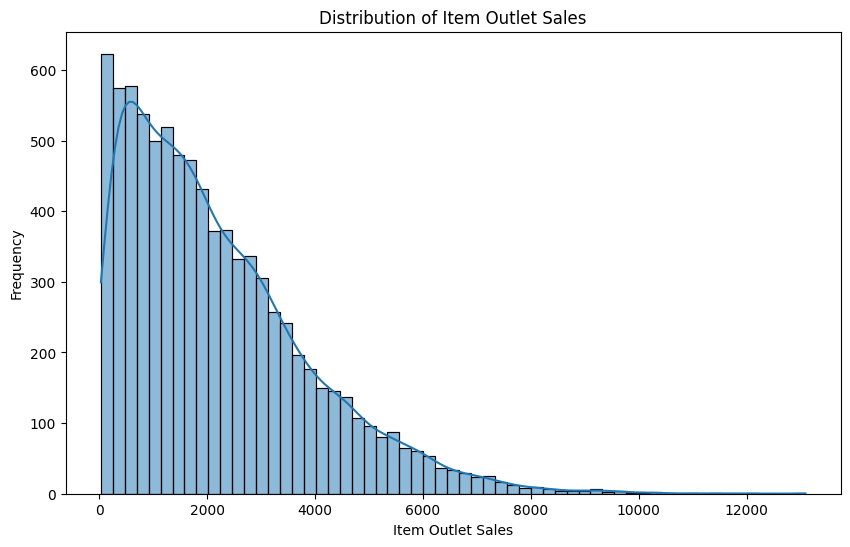

In [ ]:
# 1. Distribution of Item Sales
plt.figure(figsize=(10, 6))
sns.histplot(data['Item_Outlet_Sales'], kde=True)
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Frequency')
plt.show()

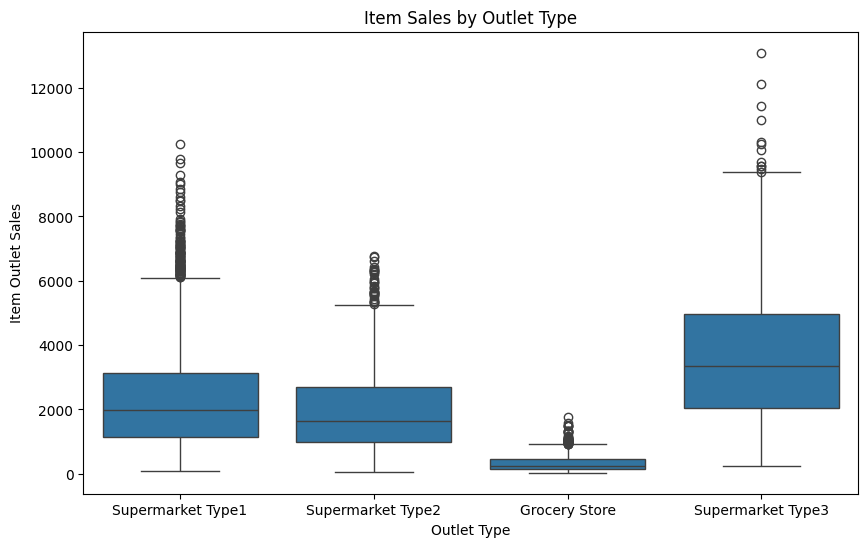

In [ ]:
# 2. Item Sales by Outlet Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=data)
plt.title('Item Sales by Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Item Outlet Sales')
plt.show()

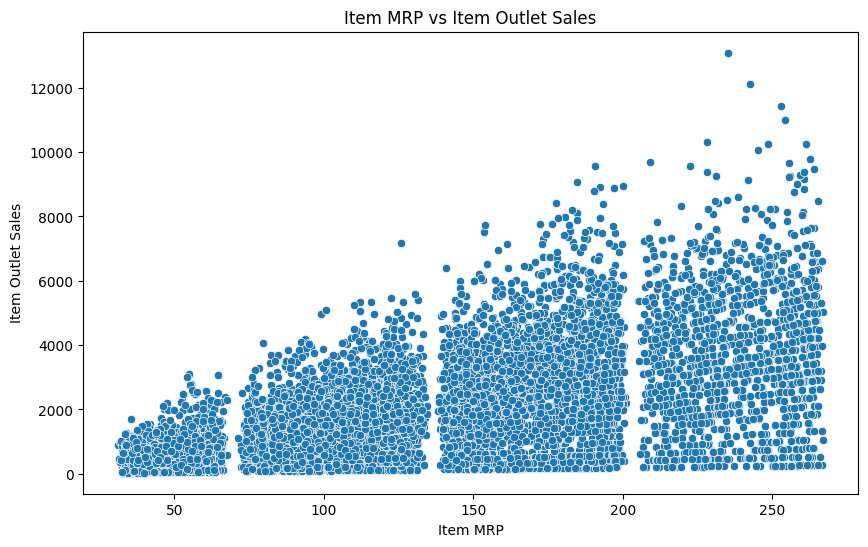

In [ ]:
# 3. Correlation between Item MRP and Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=data)
plt.title('Item MRP vs Item Outlet Sales')
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')
plt.show()

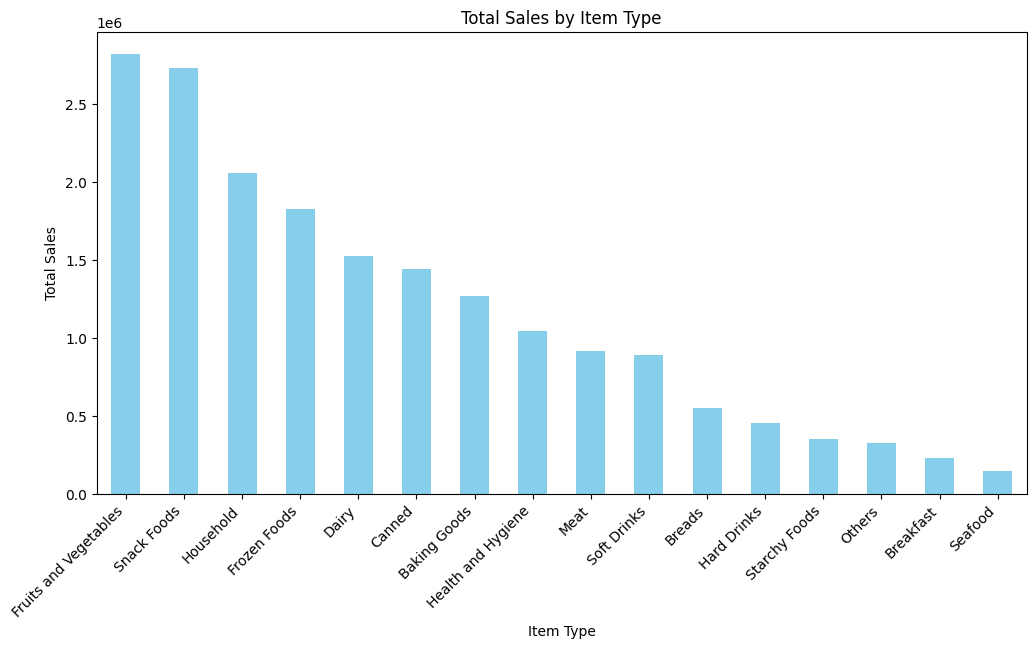

In [ ]:
# 4. Sales by Item Type
plt.figure(figsize=(12, 6))
sales_by_item = data.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)
sales_by_item.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

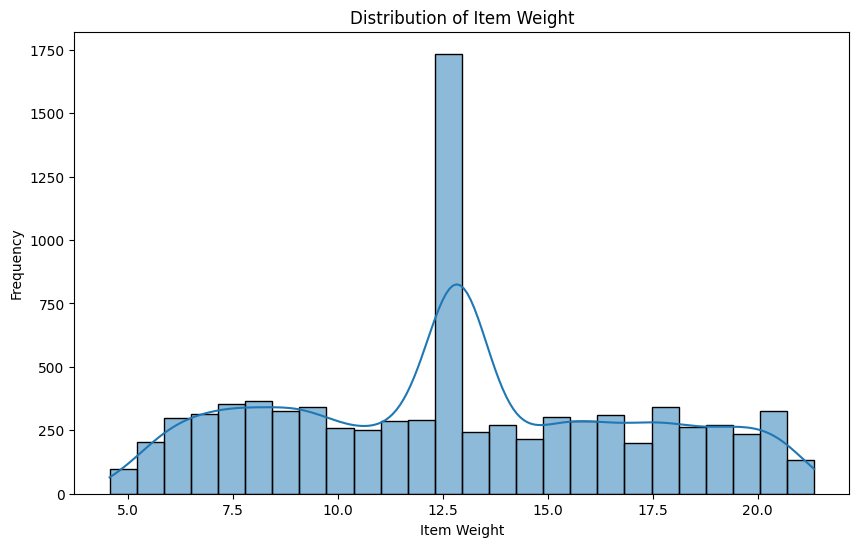

In [ ]:
# 5. Item Weight Distribution (Handling Missing Values)
plt.figure(figsize=(10, 6))
sns.histplot(data['Item_Weight'], kde=True)
plt.title('Distribution of Item Weight')
plt.xlabel('Item Weight')
plt.ylabel('Frequency')
plt.show()

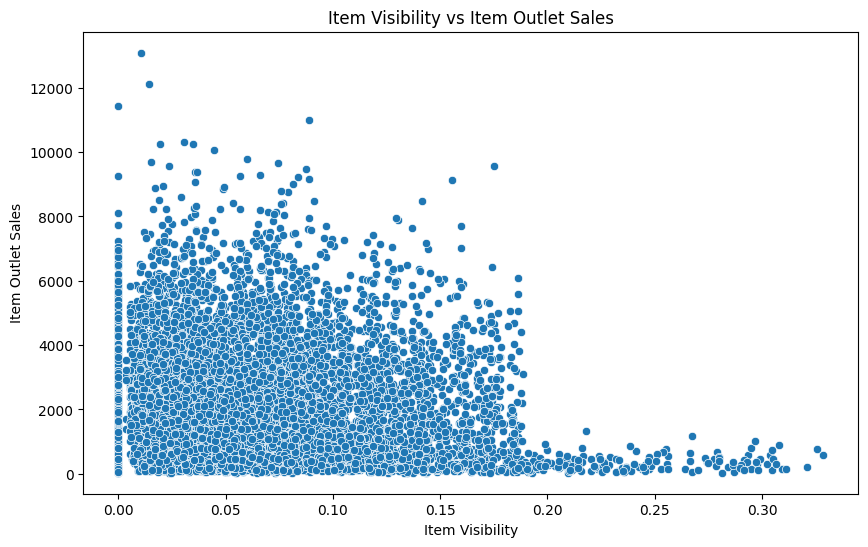

In [ ]:
# 6. Sales vs Item Visibility
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales', data=data)
plt.title('Item Visibility vs Item Outlet Sales')
plt.xlabel('Item Visibility')
plt.ylabel('Item Outlet Sales')
plt.show()

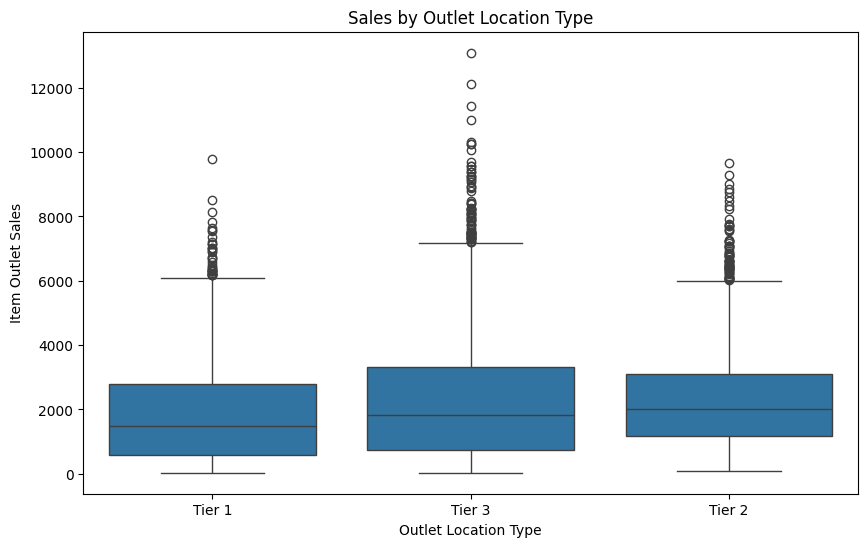

In [ ]:
# 7. Sales by Outlet Location Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', data=data)
plt.title('Sales by Outlet Location Type')
plt.xlabel('Outlet Location Type')
plt.ylabel('Item Outlet Sales')
plt.show()

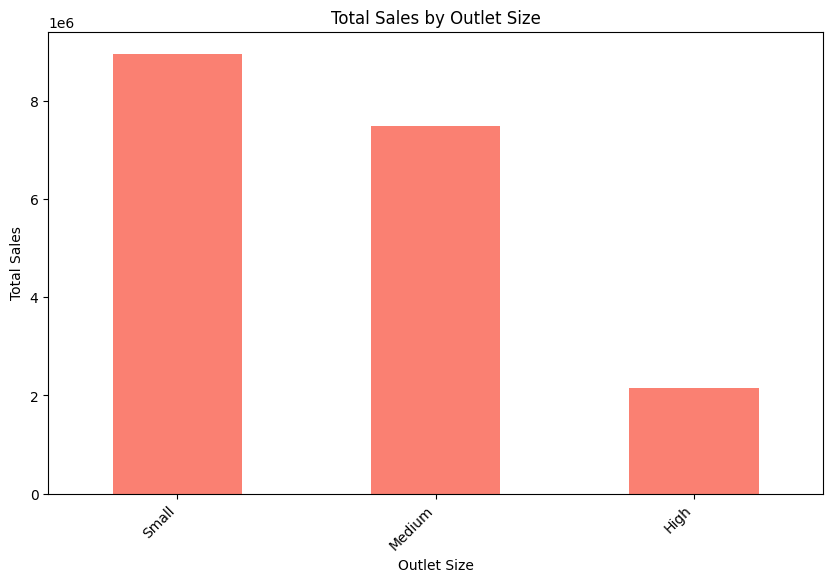

In [ ]:
# 8. Sales by Outlet Size
plt.figure(figsize=(10, 6))
sales_by_size = data.groupby('Outlet_Size')['Item_Outlet_Sales'].sum().sort_values(ascending=False)
sales_by_size.plot(kind='bar', color='salmon')
plt.title('Total Sales by Outlet Size')
plt.xlabel('Outlet Size')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

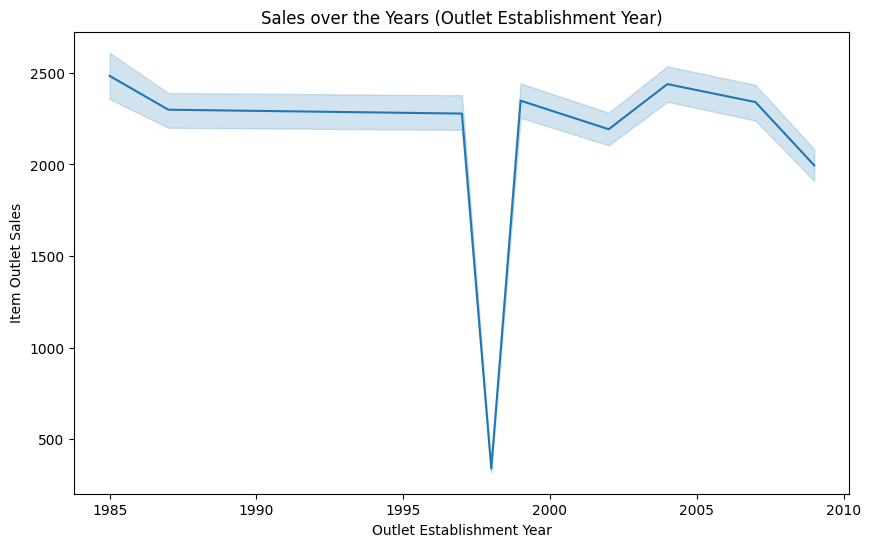

In [ ]:
# 9. Outlet Establishment Year vs Sales
plt.figure(figsize=(10, 6))
sns.lineplot(x='Outlet_Establishment_Year', y='Item_Outlet_Sales', data=data)
plt.title('Sales over the Years (Outlet Establishment Year)')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Item Outlet Sales')
plt.show()

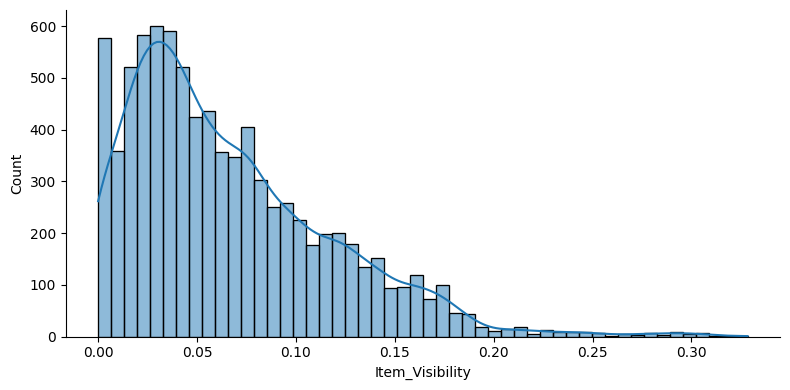

In [ ]:
sns.displot(data['Item_Visibility'],height=4, aspect=2,kde=True)
plt.show()

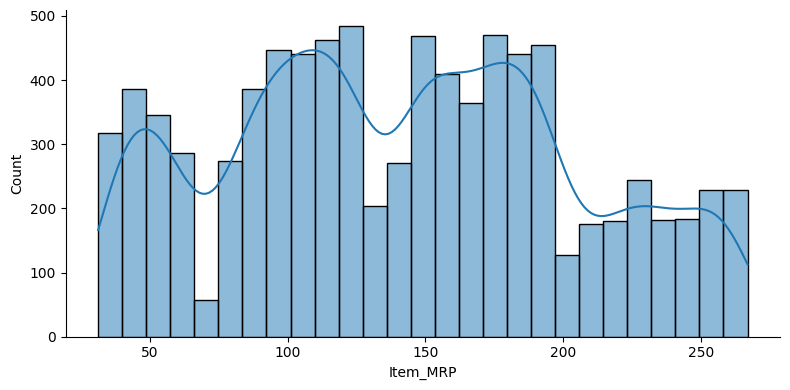

In [ ]:
sns.displot(data['Item_MRP'],height=4, aspect=2,kde=True)
plt.show()

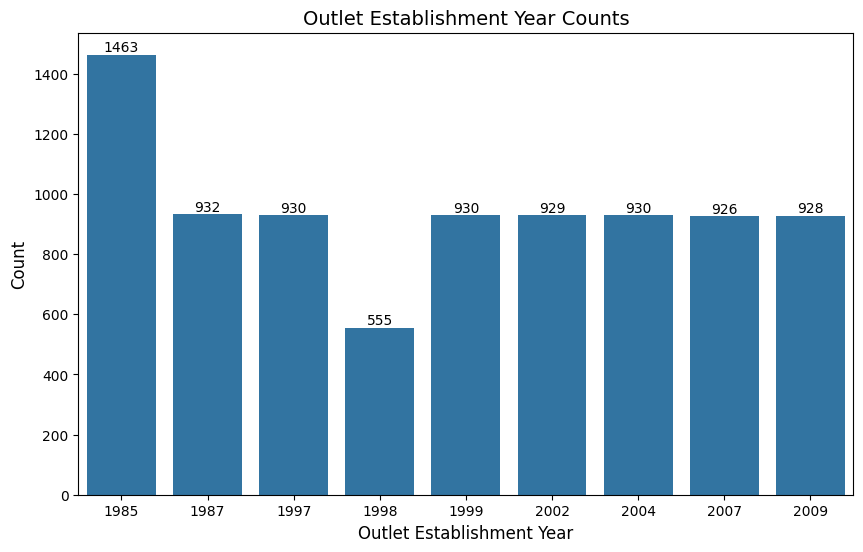

In [ ]:
# Set the size of the plot
plt.figure(figsize=(10, 6))

# Create the countplot
ax = sns.countplot(x='Outlet_Establishment_Year', data=data)

# Annotate the count above each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',  # The count (height of the bar)
        (p.get_x() + p.get_width() / 2, p.get_height()),  # Position: center of the bar and top
        ha='center', va='bottom', fontsize=10  # Center the text horizontally and position it above the bar
    )

# Display the plot
plt.title('Outlet Establishment Year Counts', fontsize=14)
plt.xlabel('Outlet Establishment Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

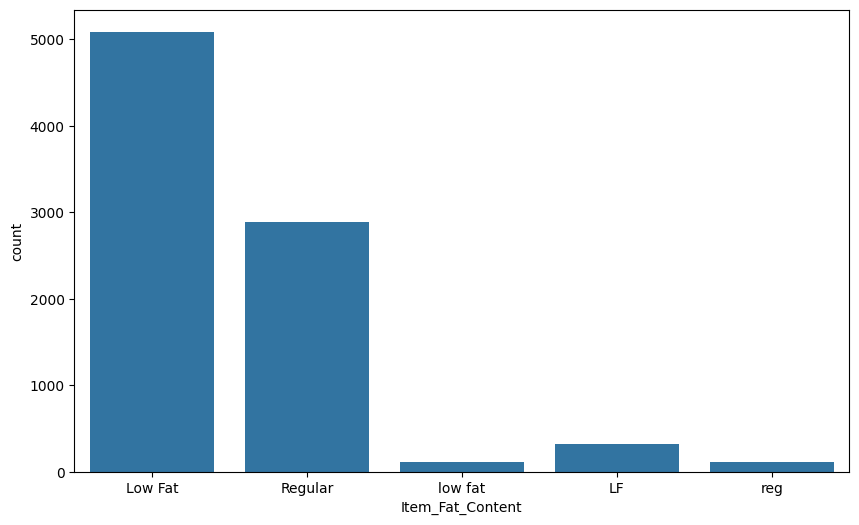

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Item_Fat_Content',data=data)
plt.show()

In [ ]:
data.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,Small,Tier 3,Grocery Store,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
data.replace({'Item_Fat_Content': {'low fat':'Low Fat','LF':'Low Fat','reg':'Regular'}}, inplace=True)

In [ ]:
data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [ ]:
data['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular'], dtype=object)

In [ ]:
data['Item_Type'].unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [ ]:
data['Outlet_Establishment_Year'].unique()

array([1999, 2009, 1998, 1987, 1985, 2002, 2007, 1997, 2004])

In [ ]:
data['Outlet_Size'].unique()

array(['Medium', 'Small', 'High'], dtype=object)

In [ ]:
data['Outlet_Location_Type'].unique()

array(['Tier 1', 'Tier 3', 'Tier 2'], dtype=object)

In [ ]:
data['Outlet_Type'].unique()

array(['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
       'Supermarket Type3'], dtype=object)

In [ ]:
le = LabelEncoder()

In [ ]:
data['Item_Fat_Content'] = le.fit_transform(data['Item_Fat_Content'])
data['Item_Type'] = le.fit_transform(data['Item_Type'])
data['Outlet_Size'] = le.fit_transform(data['Outlet_Size'])
data['Outlet_Location_Type'] = le.fit_transform(data['Outlet_Location_Type'])
data['Outlet_Type'] = le.fit_transform(data['Outlet_Type'])

In [ ]:
data.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,0,0.016047,4,249.8092,1999,1,0,1,3735.1380
1,5.92,1,0.019278,14,48.2692,2009,1,2,2,443.4228
2,17.50,0,0.016760,10,141.6180,1999,1,0,1,2097.2700
3,19.20,1,0.000000,6,182.0950,1998,2,2,0,732.3800
4,8.93,0,0.000000,9,53.8614,1987,0,2,1,994.7052


In [ ]:
data['Item_Visibility'].min()

0.0

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Fat_Content           8523 non-null   int64  
 2   Item_Visibility            8523 non-null   float64
 3   Item_Type                  8523 non-null   int64  
 4   Item_MRP                   8523 non-null   float64
 5   Outlet_Establishment_Year  8523 non-null   int64  
 6   Outlet_Size                8523 non-null   int64  
 7   Outlet_Location_Type       8523 non-null   int64  
 8   Outlet_Type                8523 non-null   int64  
 9   Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 666.0 KB


In [ ]:
data['Item_Fat_Content'].unique()

array([0, 1])

0 refers to 'Low Fat'

1 refers to 'Regular'

In [ ]:
data['Item_Type'].unique()

array([ 4, 14, 10,  6,  9,  0, 13,  5,  2,  8,  7,  3,  1, 15, 11, 12])

0 → Baking Goods
1 → Breads
2 → Canned
3 → Dairy
4 → Frozen Foods
5 → Fruits and Vegetables
6 → Hard Drinks
7 → Health and Hygiene
8 → Household
9 → Meat
10 → Others
11 → Seafood
12 → Soft Drinks
13 → Snack Foods
14 → Starchy Foods

In [ ]:
data['Outlet_Size'].unique()

array([1, 2, 0])

0 → High
1 → Medium
2 → Small

In [ ]:
data['Outlet_Location_Type'].unique()

array([0, 2, 1])

0 → Tier 1
1 → Tier 2
2 → Tier 3

In [ ]:
data['Outlet_Type'].unique()

array([1, 2, 0, 3])

0 → Grocery Store
1 → Supermarket Type1
2 → Supermarket Type2
3 → Supermarket Type3

In [ ]:
X = data.drop(columns='Item_Outlet_Sales',axis=1)
y = data['Item_Outlet_Sales']

In [ ]:
X.shape

(8523, 9)

In [ ]:
y.shape

(8523,)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_linear = linear_model.predict(X_test)

In [ ]:
r2_linear = r2_score(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)

In [ ]:
print("Linear Regression Results:")
print(f"R2 Score: {r2_linear:.4f}")
print(f"MAE: {mae_linear:.4f}")
print(f"MSE: {mse_linear:.4f}")
print(f"RMSE: {rmse_linear:.4f}")

Linear Regression Results:
R2 Score: 0.4862
MAE: 947.0919
MSE: 1586003.7592
RMSE: 1259.3664


In [ ]:
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred_tree = decision_tree_model.predict(X_test)

In [ ]:
r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)

In [ ]:
print("Decision Tree Regressor Results:")
print(f"R2 Score: {r2_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")
print(f"MSE: {mse_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")

Decision Tree Regressor Results:
R2 Score: 0.2417
MAE: 1081.8407
MSE: 2340946.4732
RMSE: 1530.0152


In [ ]:
random_forest_model = RandomForestRegressor(random_state=42, n_estimators=100)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = random_forest_model.predict(X_test)

In [ ]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

In [ ]:
print("Random Forest Regressor Results:")
print(f"R2 Score: {r2_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")

Random Forest Regressor Results:
R2 Score: 0.5459
MAE: 829.2718
MSE: 1401806.3390
RMSE: 1183.9790


In [ ]:
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
gradient_boosting_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
y_pred_gb = gradient_boosting_model.predict(X_test)

In [ ]:
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)

In [ ]:
print("Gradient Boosting Regressor Results:")
print(f"R2 Score: {r2_gb:.4f}")
print(f"MAE: {mae_gb:.4f}")
print(f"MSE: {mse_gb:.4f}")
print(f"RMSE: {rmse_gb:.4f}")

Gradient Boosting Regressor Results:
R2 Score: 0.5863
MAE: 786.5476
MSE: 1277054.8024
RMSE: 1130.0685


In [ ]:
xgboost_model = XGBRegressor(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    colsample_bytree=1.0,
    subsample=1.0,
)
xgboost_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

In [ ]:
y_pred_xgb = xgboost_model.predict(X_test)

In [ ]:
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

In [ ]:
print("XGBoost Regressor Results:")
print(f"R2 Score: {r2_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"MSE: {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")

XGBoost Regressor Results:
R2 Score: 0.5639
MAE: 805.3459
MSE: 1346305.0187
RMSE: 1160.3038


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=gradient_boosting_model,
    param_distributions=param_grid,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [ ]:
best_params = random_search.best_params_
best_model = random_search.best_estimator_

In [ ]:
print("Best Parameters:", best_params)

Best Parameters: {'subsample': 1.0, 'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.1}


In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse_xgb)

In [ ]:
print("Results after HyperParameter Tuning:")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Results after HyperParameter Tuning:
R2 Score: 0.5862
MAE: 790.0580
MSE: 1277458.3356
RMSE: 1160.3038


In [ ]:
prediction = best_model.predict([[8.93,0,0.000000,9,53.8614,1987,0,2,1]])

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [ ]:
print('Sales Prediction is:', prediction)

Sales Prediction is: [860.09635897]


In [ ]:
#import pickle
#with open("sales.pkl", "wb") as model_file:
    #pickle.dump(best_model, model_file)

In [ ]:
import joblib
joblib.dump(xgboost_model, "Asales.pkl")

['Asales.pkl']